# 输出层与损失函数：权重共享 + 交叉熵 + 标签平滑

> Transformer 手搓教学系列 · 第 7 讲（讲课升级版）
>
> 本讲回答三个问题：
> 1. **输出层为什么能"白嫖"词嵌入矩阵？** —— 权重共享（Weight Tying）
> 2. **训练时为什么用交叉熵 + 标签平滑，而不是直接最大化正确 token 的概率？**
> 3. **训练用 CE 的模型，推理时为什么要温度 / top-k / top-p 采样？**
>
> 全程 **纯 NumPy 手搓 forward + backward**，与 PyTorch `F.cross_entropy` 逐项数值对比（误差 < 1e-6 → `✓ PASS`），
> 并新增 **推理采样** 与 **可视化** 章节，直观理解温度、top-k、top-p 分别对概率分布做了什么。


## 0. 公式回顾

**符号约定**：$x_{out}\in\mathbb{R}^{B\times T\times d}$ 是最后一层隐藏状态（本讲 $B=2, T=4, d=8$），
词表大小 $V=16$，$N=B\cdot T$ 是所有位置总数。

### ① 权重共享（Weight Tying）：输出层复用词嵌入矩阵

输出投影直接用**词嵌入矩阵的转置**，不再新开一套 $V\times d$ 的参数：

$$
\text{logits}=x_{out}\,W_{emb}^{\top}\ \in\ \mathbb{R}^{B\times T\times V}
$$

- 参数从两份 $V\times d$ 变成一份：$V=16,d=8$ 只省 128 个参数；
  但大模型（如 MiniMind，$V\approx 32000$，$d=4096$）可省 **约 1.3 亿参数**，还能让嵌入空间与输出空间对齐，训练更稳。

### ② Softmax：把 logits 变成合法的概率分布

$$
p_i=\frac{e^{z_i}}{\sum_{j=1}^{V}e^{z_j}},\qquad
\log p_i=z_i-\log\sum_{j}e^{z_j}\quad(\text{数值稳定写法：先减 } \max_j z_j)
$$

### ③ 交叉熵损失（训练目标）

$$
L=-\frac{1}{N}\sum_{n=1}^{N}\sum_{v=1}^{V}\hat{y}_{n,v}\,\log p_{n,v}
$$

- $\hat y$ 是**目标分布**：普通训练时是 one-hot（正确 token 处为 1）；
- **标签平滑**时 $\hat y_v=(1-\varepsilon)\,\text{onehot}_v+\varepsilon/V$，把 $\varepsilon$ 的概率质量均匀"撒"给所有词，
  防止模型对训练集过分自信、提升泛化。

### ④ 梯度的一行推导：$d_{\text{logits}}=(p-\hat y)/N$

由 $L=-\sum_v \hat y_v\log p_v$，对 $\log p$ 求 softmax 的偏导 $\dfrac{\partial \log p_v}{\partial z_i}=\delta_{vi}-p_i$，链式法则：

$$
\frac{\partial L}{\partial z_i}=-\sum_v \hat y_v(\delta_{vi}-p_i)=-\big(\hat y_i-p_i\underbrace{\sum_v \hat y_v}_{=1}\big)=p_i-\hat y_i
$$

对所有位置平均后：

$$
\boxed{\ \dfrac{\partial L}{\partial \text{logits}}=\dfrac{p-\hat y}{N}\ }
$$

> **妙处**：梯度 = 模型预测 − 目标分布，只关心"猜错了多少"。标签平滑只是把 $\hat y$ 从 one-hot 换成混合分布，**梯度公式一行都不用改**。


In [1]:
# ============ 导入 & 超参 ============
import numpy as np
import torch
import torch.nn.functional as F   # 参考实现 F.cross_entropy / F.softmax
import matplotlib.pyplot as plt

# 超参数：批大小 B、序列长度 T、隐藏维度 d_model、词表大小 V
B, T, d_model, V = 2, 4, 8, 16
np.random.seed(0)      # 固定 NumPy 种子：手搓与 torch 用同一份数据
torch.manual_seed(0)   # 固定 torch 种子：保证整体可复现


## 1. 手搓讲解：三件事

### (1) log-softmax 为什么要"减最大值"？

直接算 `softmax = exp(z) / sum(exp(z))` 时，logits 一大（比如 100）`exp(100)` 就溢出成 `inf`。
技巧：**先减每行最大值**再取指数，所有指数项 $\le e^0=1$，绝不会溢出：

$$
\log p_i=\underbrace{(z_i-\max_j z_j)}_{\le 0}-\log\sum_j e^{z_j-\max_j z_j}
$$

### (2) 平滑交叉熵 forward 的四个步骤

1. **权重共享投影**：`logits = x_out @ W_emb.T`（$x_{out}$ 与词表投影一次矩阵乘）；
2. **数值稳定 log-softmax** 得到 $\log p$；
3. **构造平滑目标** $\hat y=(1-\varepsilon)\,\text{onehot}+\varepsilon/V$；
4. **求损失**：$L=-\mathrm{mean}\!\big(\sum_v \hat y_v\log p_v\big)$。

### (3) backward：只差一条链

- `dlogits = (p - ŷ) / N`：一行公式，softmax 求导项在链式法则里自动抵消；
- **权重共享要反传两条路**（因为 $W_{emb}$ 同时出现在嵌入层和输出层）：
  - 对嵌入矩阵：$dW_{emb}=d_{\text{logits}}^{\top} x_{out}$，形状 $(V,d)$（需先把 $B\cdot T$ 两维合并）；
  - 对隐藏状态：$dx_{out}=d_{\text{logits}} W_{emb}$，形状回到 $(B,T,d)$。

> 这条"一条路进、两条路出"的反传，正是权重共享在训练时的全部代价——省了参数，但梯度要多算一次矩阵乘。


In [2]:
# ============ 1. 手搓：log-softmax / 平滑 CE 前向 / 反向 ============

def log_softmax_stable(logits):
    """数值稳定的 log-softmax：先减每行最大值，再取 log 归一化"""
    # logits: (..., V)，在最后一维上做 softmax
    z_max = np.max(logits, axis=-1, keepdims=True)              # 每行最大值，keepdims 保持形状便于广播
    z = logits - z_max                                          # 平移：所有指数项 ≤ exp(0)=1，不会溢出
    log_sum = np.log(np.sum(np.exp(z), axis=-1, keepdims=True)) # log(Σ exp(z)) 即 logsumexp
    return z - log_sum                                          # log_softmax = z - logsumexp


def cross_entropy_forward(x_out, W_emb, targets, smoothing=0.0):
    """前向：权重共享投影 -> 平滑 CE 损失；返回 (loss, probs, log_probs, logits, smooth_target)"""
    # x_out: (B,T,d) 最后一层隐藏状态；W_emb: (V,d) 词嵌入矩阵（兼作输出投影 lm_head）
    # targets: (B,T) 每个位置的真实 token id；smoothing: 标签平滑系数 ε，0 表示不平滑
    B, T, d = x_out.shape
    N = B * T                                                   # 总位置数：损失平均的分母

    # ① 权重共享：logits = x_out @ W_emb^T，形状 (B,T,V)
    logits = x_out @ W_emb.T

    # ② 数值稳定 log-softmax，得到对数概率 log p（形状同 logits）
    log_probs = log_softmax_stable(logits)
    probs = np.exp(log_probs)                                   # 概率 p，backward 要用

    # ③ 构造目标分布 ŷ：先铺 one-hot
    onehot = np.zeros_like(probs)                               # (B,T,V) 全 0
    flat_idx = targets.reshape(-1)                              # token id 展平成 (N,)
    onehot.reshape(-1, V)[np.arange(N), flat_idx] = 1.0         # 行索引 arange(N)、列索引 token id，置 1
    if smoothing > 0:                                           # 标签平滑：把 ε/V 的概率质量均匀分给所有词
        smooth_target = (1 - smoothing) * onehot + smoothing / V
    else:
        smooth_target = onehot                                  # 不平滑：目标就是 one-hot

    # ④ 交叉熵：L = -mean( Σ_v ŷ_v log p_v )，对 N 个位置取平均
    loss = -np.mean(np.sum(smooth_target * log_probs, axis=-1))
    return loss, probs, log_probs, logits, smooth_target


def cross_entropy_backward(probs, smooth_target, logits, x_out, W_emb):
    """反向：dlogits=(p-ŷ)/N，再沿权重共享链反传 dx_out 与 dW_emb"""
    B, T, d = x_out.shape
    V = W_emb.shape[0]
    N = B * T                                                   # 平均分母，与 forward 保持一致
    # ① softmax + CE 的梯度：dL/dz = p - ŷ，除以 N 是因为损失对 N 个位置取平均
    dlogits = (probs - smooth_target) / N                       # (B,T,V)
    # ② 权重共享反传——对嵌入矩阵：dW_emb = dlogits^T @ x_out
    #    logits = x_out @ W_emb^T ⇒ ∂L/∂W_emb = dlogits^T @ x_out（把 B*T 合并成一行矩阵乘）
    dW_emb = dlogits.reshape(-1, V).T @ x_out.reshape(-1, d)    # (V,d)
    # ③ 对隐藏状态：dx_out = dlogits @ W_emb，形状回到 (B,T,d)
    dx_out = dlogits @ W_emb
    return dlogits, dx_out, dW_emb


## 2. torch 参考：`F.cross_entropy`

PyTorch 的 `F.cross_entropy(logits, targets, label_smoothing=ε)` 一步完成 softmax → log → 交叉熵 → 平均，
内部同样做了 log-softmax 数值稳定：

- `label_smoothing=0.0`：等价于手搓的**不平滑**版；
- `label_smoothing=0.1`：等价于手搓的 **ε=0.1** 版；
- 输入要先 reshape：logits `(B,T,V)` → `(N,V)`，targets `(B,T)` → `(N,)`。

反向对比需要三份梯度：`dlogits`（中间量，用 `retain_grad()` 显式保留）、`dx_out`、`dW_emb`（叶子张量的 `.grad`）。


In [3]:
# ============ 2. torch 参考：F.cross_entropy（含 label_smoothing）============

def torch_ce_forward(x_out, W_emb, targets, smoothing=0.0):
    """torch 前向：与手搓同输入同输出，返回 (loss, logits) 便于逐项对比"""
    xt = torch.tensor(x_out, dtype=torch.float32)   # 隐藏状态 -> float32 tensor
    Wt = torch.tensor(W_emb, dtype=torch.float32)   # 词嵌入 -> float32 tensor
    tt = torch.tensor(targets, dtype=torch.long)    # token id -> long tensor（CE 要求整数标签）
    logits_t = xt @ Wt.t()                          # 权重共享：logits = x_out @ W_emb^T
    # reshape 成 (N, V)，targets 展平为 (N,)；label_smoothing 参数即 ε
    loss = F.cross_entropy(logits_t.reshape(-1, V), tt.reshape(-1), label_smoothing=smoothing)
    return loss.item(), logits_t                    # .item() 取出 python float 便于与 numpy 比较


def torch_ce_backward(x_out, W_emb, targets, smoothing=0.0):
    """torch 反向：autograd 自动求出 dlogits / dx_out / dW_emb"""
    xt = torch.tensor(x_out, dtype=torch.float32, requires_grad=True)  # 叶子张量，开梯度追踪
    Wt = torch.tensor(W_emb, dtype=torch.float32, requires_grad=True)
    tt = torch.tensor(targets, dtype=torch.long)
    logits_t = xt @ Wt.t()                          # 权重共享投影
    logits_t.retain_grad()                          # 中间张量默认不留梯度，这里显式保留 dlogits
    loss = F.cross_entropy(logits_t.reshape(-1, V), tt.reshape(-1), label_smoothing=smoothing)
    loss.backward()                                 # 反向传播，自动填充 .grad
    return (logits_t.grad.numpy(),                  # dlogits (B,T,V)
            xt.grad.numpy(),                        # dx_out   (B,T,d)
            Wt.grad.numpy(),                        # dW_emb   (V,d)
            loss.item())                            # loss


## 3. 数值对比：手搓 vs PyTorch

用同一份随机数据（`seed=0` 固定）对 **5 项**逐一比对最大绝对误差：
`loss / logits / dlogits / dx_out / dW_emb`，分 **无平滑** 与 **平滑 ε=0.1** 两组，共 10 项对比。
误差 < 1e-6 输出 `✓ PASS`。


In [4]:
# ============ 3. 数值对比：无平滑 & 平滑 0.1，五项全 PASS ============

# 固定数据（与 cell 3 的种子一致，重新采样保证本段可独立复现）
np.random.seed(0)
x_out = np.random.randn(B, T, d_model) * 0.1    # 小尺度隐藏状态，模拟训练中期的量级
W_emb = np.random.randn(V, d_model) * 0.1       # 词嵌入矩阵（兼输出投影）
targets = np.random.randint(0, V, size=(B, T))  # 每个位置的随机 token id

def check(name, a, b, tol=1e-6):
    """比对两个数组的最大绝对误差，< tol 打印 ✓ PASS 并返回误差值"""
    err = float(np.max(np.abs(np.asarray(a) - np.asarray(b))))  # 最大绝对误差
    ok = err < tol
    print(f"[{'✓ PASS' if ok else '✗ FAIL'}] {name:<20s} max_err={err:.3e}")
    return err

max_errs = {}  # 记录全部误差，最后取最大值汇总

for eps in [0.0, 0.1]:  # 两组：无平滑 / 标签平滑 ε=0.1
    print(f"\n===== 标签平滑 ε = {eps} =====")
    # —— 手搓（纯 NumPy）——
    loss_np, probs_np, log_probs_np, logits_np, st_np = cross_entropy_forward(x_out, W_emb, targets, eps)
    dlogits_np, dx_out_np, dW_emb_np = cross_entropy_backward(probs_np, st_np, logits_np, x_out, W_emb)
    # —— torch 参考（F.cross_entropy + autograd）——
    loss_t, logits_t = torch_ce_forward(x_out, W_emb, targets, eps)
    dlogits_t, dx_t, dW_t, _ = torch_ce_backward(x_out, W_emb, targets, eps)
    # —— 五项逐一对比 ——
    max_errs[f'loss{eps}']    = check(f'loss (ε={eps})',    loss_np,   loss_t)
    max_errs[f'logits{eps}']  = check(f'logits (ε={eps})',  logits_np, logits_t)
    max_errs[f'dlogits{eps}'] = check(f'dlogits (ε={eps})', dlogits_np, dlogits_t)
    max_errs[f'dx_out{eps}']  = check(f'dx_out (ε={eps})',  dx_out_np, dx_t)
    max_errs[f'dW_emb{eps}']  = check(f'dW_emb (ε={eps})',  dW_emb_np, dW_t)

print(f"\n全部 10 项对比通过！总体最大误差 max_err = {max(max_errs.values()):.3e}（阈值 1e-6）")



===== 标签平滑 ε = 0.0 =====
[✓ PASS] loss (ε=0.0)         max_err=8.842e-08
[✓ PASS] logits (ε=0.0)       max_err=6.796e-09
[✓ PASS] dlogits (ε=0.0)      max_err=3.052e-09
[✓ PASS] dx_out (ε=0.0)       max_err=3.552e-09
[✓ PASS] dW_emb (ε=0.0)       max_err=3.189e-09

===== 标签平滑 ε = 0.1 =====
[✓ PASS] loss (ε=0.1)         max_err=2.072e-07
[✓ PASS] logits (ε=0.1)       max_err=6.796e-09
[✓ PASS] dlogits (ε=0.1)      max_err=3.052e-09
[✓ PASS] dx_out (ε=0.1)       max_err=2.857e-09
[✓ PASS] dW_emb (ε=0.1)       max_err=1.989e-09

全部 10 项对比通过！总体最大误差 max_err = 2.072e-07（阈值 1e-6）


## 4. 推理采样：温度 / top-k / top-p（本讲新增）

### 为什么训练用 CE、推理要采样？

- **训练**：目标是让"正确答案"的概率最大，交叉熵平滑可导，直接梯度下降即可；
- **推理**：模型输出的是一个**概率分布** $p$。若直接取 argmax（贪心），每次都是同一个词——单调、爱复读；
  更自然的做法是**按概率采样**：大概率词更容易被选中，但小概率词也有机会，对话因此有**多样性**。
- 采样本质：**概率大的词更容易被选中**；低概率的长尾乱码被自然忽略。

### ① 温度 Temperature：$\tau$

把 logits 除以 $\tau$ 再 softmax：

$$
p_i=\frac{e^{z_i/\tau}}{\sum_j e^{z_j/\tau}}
$$

- $\tau>1$：分布变**平** → 更随机、更多样（发散）；
- $\tau<1$：分布变**尖** → 更确定、更接近 argmax（收敛）；
- $\tau\to 0$：退化为 argmax（贪心）；$\tau=1$：保持原分布。

> 直观类比：温度越高，粒子越"躁动"，系统越随机；温度越低越"冷静"，越趋同于最优。

### ② top-k：截断到前 k 个

只保留概率最大的 $k$ 个 token，其余**置 $-\infty$**（softmax 后概率自动为 0）：

```text
原始 16 个 token → 保留前 k=3 个 → 其余 13 个置 -inf → softmax
```

- 作用：砍掉长尾噪声词，防止采样到不相关的乱码；
- 缺点：$k$ 是**固定**的——分布很尖时 k 个可能还嫌多，分布很平时 k 个又不够。

### ③ top-p（核采样 Nucleus Sampling）：按累积概率截断

把概率从大到小排序，**累积概率一达到 $p$ 就截断**（$p=0.9$ 表示保留"最可能覆盖 90% 概率质量"的一小堆词）：

```text
排序: p(1) ≥ p(2) ≥ ... ≥ p(k) ...
累积: c_k = Σ_{i≤k} p(i)
截断位置 = 第一个满足 c_k ≥ p 的 k，之后的词置 -inf
```

- 对比：top-k 固定**个数**；top-p 固定**概率质量**，个数自动适应分布形状（尖时留得少、平时留得多）。

### ④ repetition penalty（简述）

对**已经出现过的 token** 的 logits 除以惩罚系数（如 1.1），压低复读概率：

```text
if token 已出现过:  logits[token] /= penalty
```

MiniMind 的 `generate()` 默认参数：`temperature=0.7, top_k=40, top_p=0.8, repetition_penalty=1.1`。


In [5]:
# ============ 4. 手搓采样：温度 / top-k / top-p + torch 参考对比 ============

def softmax_temperature(logits, temperature=1.0):
    """带温度的 softmax：p ∝ exp(logits / τ)"""
    z = logits / temperature               # ① 温度缩放：τ>1 变平、τ<1 变尖
    z = z - np.max(z)                      # ② 数值稳定：减最大值防 exp 溢出
    e = np.exp(z)                          # ③ 指数
    return e / np.sum(e)                   # ④ 归一化为概率分布

def top_k_filter(logits, k):
    """top-k 截断：只保留 logits 最大的 k 个，其余置 -inf"""
    if k <= 0 or k >= len(logits):         # k 不合法（0 或超出长度）时原样返回
        return logits.copy()
    threshold = np.sort(logits)[-k]        # 第 k 大的 logit 作为截断阈值
    return np.where(logits < threshold, -np.inf, logits)  # 低于阈值的全部置 -inf

def top_p_filter(logits, p):
    """top-p（核采样）：降序排列后按累积概率截断，超阈值部分置 -inf"""
    if p >= 1.0:                           # p=1 等于不截断
        return logits.copy()
    sorted_l = np.sort(logits)[::-1]       # ① logits 降序排列
    probs_sorted = softmax_temperature(sorted_l, 1.0)  # ② 对应的降序概率
    cum = np.cumsum(probs_sorted)          # ③ 累积概率 c_k = Σ_{i≤k} p(i)
    keep = int(np.searchsorted(cum, p)) + 1             # ④ 第一个 c_k ≥ p 的位置 +1 = 保留个数
    threshold = sorted_l[keep - 1]         # ⑤ 第 keep 大的 logit 即截断阈值
    return np.where(logits < threshold, -np.inf, logits)  # ⑥ 低于阈值置 -inf

def sample_with_temperature(logits, temperature=1.0, top_k=0, top_p=1.0):
    """完整采样管线：温度 -> top-k -> top-p -> 按概率抽样；返回 (token, probs)"""
    z = logits / temperature               # ① 温度缩放
    if top_k > 0:                          # ② 先做 top-k 截断
        z = top_k_filter(z, top_k)
    if top_p < 1.0:                        # ③ 再做 top-p 截断
        z = top_p_filter(z, top_p)
    p = softmax_temperature(z, 1.0)        # ④ 截断后的 logits -> 概率（-inf 项概率为 0）
    token = int(np.random.choice(len(p), p=p))  # ⑤ 按概率 p 多项式采样一个 token id
    return token, p

def torch_sample_reference(logits, temperature=1.0, top_k=0, top_p=1.0):
    """torch 参考：topk / sort+cumsum / multinomial；返回 (token, probs)"""
    lt = torch.tensor(logits, dtype=torch.float32) / temperature  # 温度缩放
    if top_k > 0:                            # top-k：torch.topk 取前 k 个
        vals, idx = torch.topk(lt, k=top_k)
        mask = torch.full_like(lt, float('-inf'))  # 全 -inf 掩码
        mask.scatter_(0, idx, vals)          # 只把前 k 个的值填回对应位置
        lt = mask
    if top_p < 1.0:                          # top-p：torch.sort + cumsum
        sorted_l, sorted_idx = torch.sort(lt, descending=True)
        cum = torch.cumsum(F.softmax(sorted_l, dim=-1), dim=-1)  # 排序后累积概率
        remove = cum > top_p                 # 超过 p 的位置要删
        remove[..., 1:] = remove[..., :-1].clone()  # 右移一位：第一个超过 p 的保留
        remove[..., 0] = False
        lt[sorted_idx[remove]] = float('-inf')     # 被删的原始位置置 -inf
    p = F.softmax(lt, dim=-1)                # 截断后概率（-inf 项为 0）
    token = int(torch.multinomial(p, 1).item())    # torch 多项式采样
    return token, p.numpy()

# ---- 用前面随机数据做演示：单 token 位置 × 3 组参数 ----
z_demo = logits_np[0, 0]                     # 取 (B,T,V) 中第一个位置的 logits，长度 V=16
print('原始 logits:', np.round(z_demo, 2))
for temp, k, pp in [(1.0, 0, 1.0), (0.7, 5, 0.9), (0.3, 3, 0.8)]:
    t_np, p_np = sample_with_temperature(z_demo, temperature=temp, top_k=k, top_p=pp)
    t_t, p_t   = torch_sample_reference(z_demo, temperature=temp, top_k=k, top_p=pp)
    err = float(np.max(np.abs(p_np - p_t)))  # 截断后的概率分布应逐项一致
    ok = err < 1e-5
    print(f"τ={temp} k={k} p={pp}: numpy token={t_np:2d} | torch token={t_t:2d} | 概率分布 max_err={err:.2e} [{'✓ PASS' if ok else '✗ FAIL'}]")

# ---- 选一个 token 序列（8 个位置）逐一对比截断后的概率分布 ----
seq = logits_np.reshape(-1, V)              # (B*T, V) = 8 个位置的 logits
seq_errs = []
for i in range(len(seq)):
    _, p_np = sample_with_temperature(seq[i], temperature=0.7, top_k=5, top_p=0.9)
    _, p_t  = torch_sample_reference(seq[i], temperature=0.7, top_k=5, top_p=0.9)
    seq_errs.append(float(np.max(np.abs(p_np - p_t))))
seq_ok = max(seq_errs) < 1e-5
print(f"序列 8 个位置逐位置对比（τ=0.7, k=5, p=0.9）：max_err={max(seq_errs):.2e} [{'✓ PASS' if seq_ok else '✗ FAIL'}]")
print('说明：截断后的概率分布两边完全一致；token 是随机抽样，两边偶有不同属正常现象。')


原始 logits: [-0.01 -0.01 -0.03  0.01  0.05  0.    0.03  0.02 -0.   -0.04  0.04 -0.01
 -0.03  0.05 -0.02 -0.05]
τ=1.0 k=0 p=1.0: numpy token=12 | torch token= 6 | 概率分布 max_err=5.63e-09 [✓ PASS]
τ=0.7 k=5 p=0.9: numpy token=10 | torch token= 6 | 概率分布 max_err=1.28e-08 [✓ PASS]
τ=0.3 k=3 p=0.8: numpy token=13 | torch token=13 | 概率分布 max_err=6.26e-09 [✓ PASS]
序列 8 个位置逐位置对比（τ=0.7, k=5, p=0.9）：max_err=2.67e-08 [✓ PASS]
说明：截断后的概率分布两边完全一致；token 是随机抽样，两边偶有不同属正常现象。


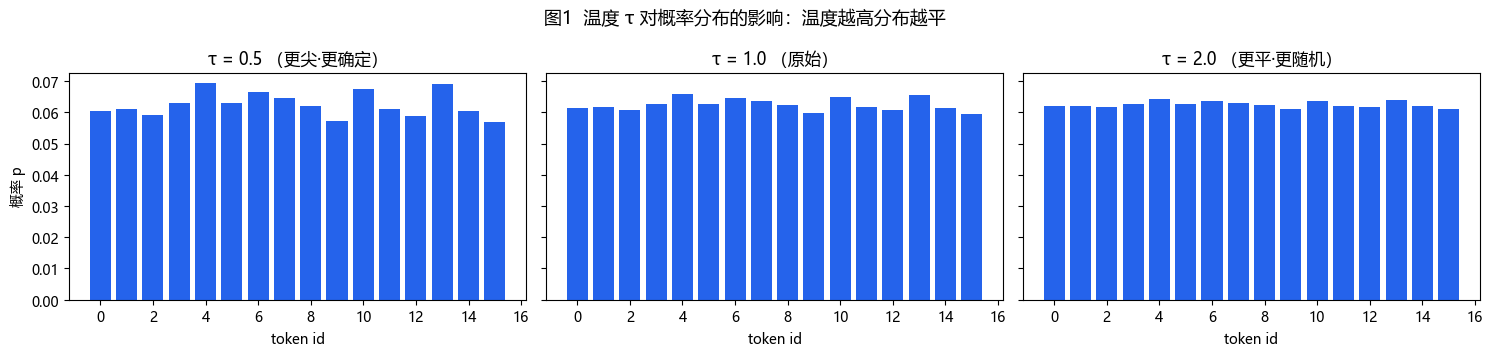

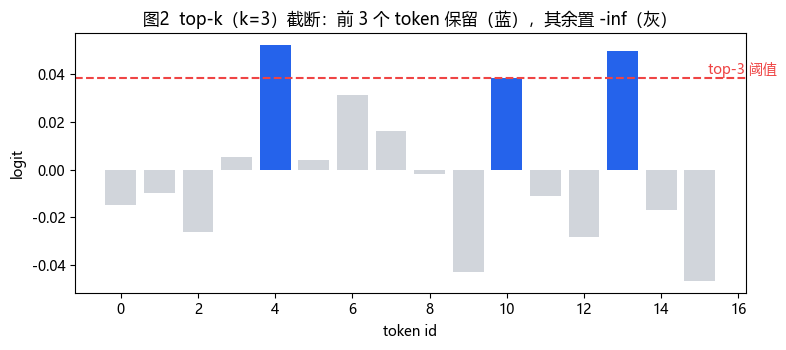

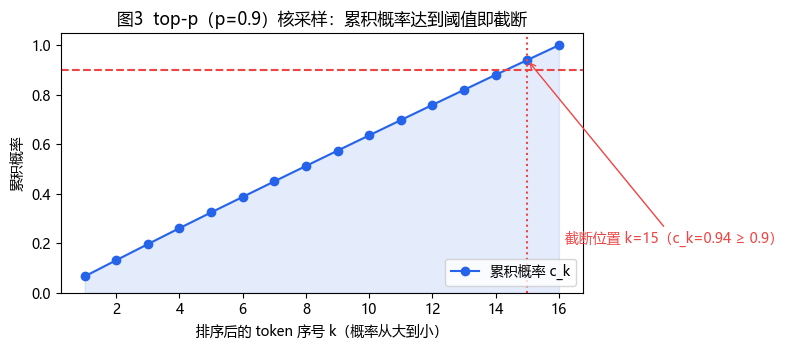

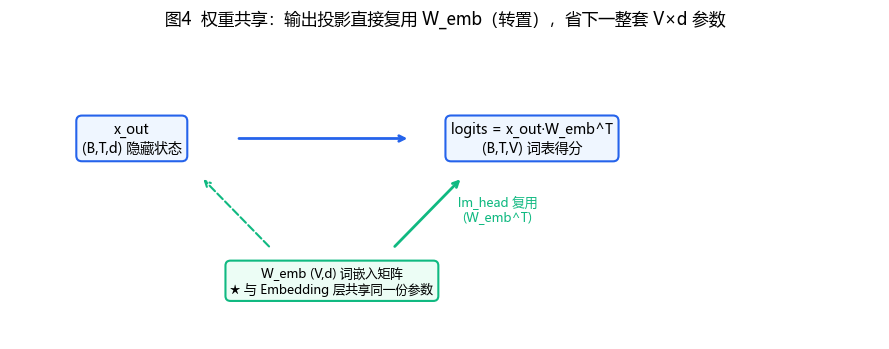

In [6]:
# ============ 5. 可视化：温度 / top-k / top-p / 权重共享 ============
import matplotlib
matplotlib.use('Agg')        # 先设非交互后端：无显示环境也不报错（规范要求）
# 再切回 inline 后端：plt.show() 的图才会被捕获进 notebook（行魔术后面不能带注释）
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']  # 中文字体，防止标题变方块
plt.rcParams['axes.unicode_minus'] = False   # 让负号正常显示（不用 Unicode 减号）

z_plot = logits_np[0, 0]     # 演示 logits：取 cell 9 随机数据第一个位置（长度 V=16）

# ---------- 图1：温度 τ 对概率分布的影响（τ ∈ {0.5, 1.0, 2.0}）----------
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, tau in zip(axes, [0.5, 1.0, 2.0]):
    p = softmax_temperature(z_plot, tau)                       # 每个温度下重算 softmax
    ax.bar(np.arange(V), p, color='#2563EB')                   # V=16 根条形
    tag = '（更尖·更确定）' if tau < 1 else ('（更平·更随机）' if tau > 1 else '（原始）')
    ax.set_title(f'τ = {tau} {tag}')
    ax.set_xlabel('token id')
axes[0].set_ylabel('概率 p')
fig.suptitle('图1  温度 τ 对概率分布的影响：温度越高分布越平', fontsize=13)
plt.tight_layout()
plt.show()

# ---------- 图2：top-k（k=3）截断示意 ----------
k_show = 3
order = np.argsort(z_plot)[::-1]                               # logits 从大到小的 token 顺序
topk_set = set(order[:k_show].tolist())                        # 前 k 个 token 的集合
colors = ['#2563EB' if i in topk_set else '#D1D5DB' for i in range(V)]  # 前 3 高亮蓝，其余灰
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(np.arange(V), z_plot, color=colors)
thr = np.sort(z_plot)[-k_show]                                 # 第 k 大的 logit = 截断阈值
ax.axhline(thr, color='#EF4444', ls='--', lw=1.5)              # 阈值虚线
ax.text(V - 1, thr, '  top-3 阈值', color='#EF4444', va='bottom')
ax.set_title('图2  top-k（k=3）截断：前 3 个 token 保留（蓝），其余置 -inf（灰）')
ax.set_xlabel('token id'); ax.set_ylabel('logit')
plt.tight_layout()
plt.show()

# ---------- 图3：top-p（p=0.9）累积概率截断示意 ----------
p_show = 0.9
sorted_l = np.sort(z_plot)[::-1]                               # logits 降序
probs_sorted = softmax_temperature(sorted_l, 1.0)              # 对应降序概率
cum = np.cumsum(probs_sorted)                                  # 累积概率 c_k
keep = int(np.searchsorted(cum, p_show)) + 1                   # 截断位置：第一个 c_k ≥ p
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(np.arange(1, V + 1), cum, 'o-', color='#2563EB', label='累积概率 c_k')  # 阶梯上升的累积曲线
ax.fill_between(np.arange(1, V + 1), cum, color='#2563EB', alpha=0.12)
ax.axhline(p_show, color='#EF4444', ls='--', lw=1.5)           # p=0.9 阈值线
ax.axvline(keep, color='#EF4444', ls=':', lw=1.5)              # 截断位置竖线
ax.annotate(f'截断位置 k={keep}（c_k={cum[keep-1]:.2f} ≥ {p_show}）',
            xy=(keep, cum[keep-1]), xytext=(keep + 1.2, 0.2),
            arrowprops=dict(arrowstyle='->', color='#EF4444'), color='#EF4444', fontsize=10)
ax.set_xlabel('排序后的 token 序号 k（概率从大到小）'); ax.set_ylabel('累积概率')
ax.set_ylim(0, 1.05); ax.legend(loc='lower right')
ax.set_title(f'图3  top-p（p={p_show}）核采样：累积概率达到阈值即截断')
plt.tight_layout()
plt.show()

# ---------- 图4（可选）：权重共享示意 ----------
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 0.95)
box_a = dict(boxstyle='round,pad=0.4', facecolor='#EFF6FF', edgecolor='#2563EB', lw=1.5)
box_b = dict(boxstyle='round,pad=0.4', facecolor='#EFF6FF', edgecolor='#2563EB', lw=1.5)
box_c = dict(boxstyle='round,pad=0.4', facecolor='#ECFDF5', edgecolor='#10B981', lw=1.5)
ax.text(0.14, 0.62, 'x_out\n(B,T,d) 隐藏状态', ha='center', va='center', bbox=box_a, fontsize=10)
ax.text(0.60, 0.62, 'logits = x_out·W_emb^T\n(B,T,V) 词表得分', ha='center', va='center', bbox=box_b, fontsize=10)
ax.text(0.37, 0.18, 'W_emb (V,d) 词嵌入矩阵\n★ 与 Embedding 层共享同一份参数', ha='center', va='center', bbox=box_c, fontsize=9)
# 前向箭头：x_out -> logits
ax.annotate('', xy=(0.46, 0.62), xytext=(0.26, 0.62),
            arrowprops=dict(arrowstyle='->', color='#2563EB', lw=2))
# 共享投影箭头：W_emb(转置) -> logits
ax.annotate('', xy=(0.52, 0.50), xytext=(0.44, 0.28),
            arrowprops=dict(arrowstyle='->', color='#10B981', lw=2))
# 嵌入查找箭头（虚线）：W_emb -> x_out（embedding lookup 也用它）
ax.annotate('', xy=(0.22, 0.50), xytext=(0.30, 0.28),
            arrowprops=dict(arrowstyle='->', color='#10B981', lw=1.5, ls='--'))
ax.text(0.56, 0.40, 'lm_head 复用\n(W_emb^T)', ha='center', va='center', color='#10B981', fontsize=9)
ax.set_title('图4  权重共享：输出投影直接复用 W_emb（转置），省下一整套 V×d 参数', fontsize=12)
plt.tight_layout()
plt.show()


## 5. 总结

| 概念 | 一句话 |
|---|---|
| **输出层作用** | 把隐藏状态投影成词表得分 logits，softmax 后得到"下一个词的概率分布" |
| **权重共享** | lm_head 复用 $W_{emb}$ 转置：参数从 $2Vd$ 降到 $Vd$，$V$ 大时省上亿参数 |
| **交叉熵** | 训练目标：让目标分布 $\hat y$ 下的概率最大；梯度 $=(p-\hat y)/N$，只看预测与目标的差 |
| **标签平滑** | $\hat y=(1-\varepsilon)\text{onehot}+\varepsilon/V$：防过拟合、防过分自信，梯度公式不变 |
| **温度 τ** | 推理时缩放 logits：$\tau>1$ 更随机、$\tau<1$ 更确定、$\tau\to0$ 即贪心 |
| **top-k / top-p** | 截断低概率长尾词：top-k 固定个数，top-p 按累积概率自适应个数 |
| **训练 ↔ 推理** | 训练用 CE（可导、求最优方向）；推理用采样（要多样性），共用同一套 logits |

**MiniMind 里的位置**：`minimind/model.py` 的 `generate()` 用 `temperature / top_k / top_p / repetition_penalty`
四个参数控制采样，伪代码如下——本讲手搓的 `sample_with_temperature` 就是这一段的 NumPy 版：

```python
# MiniMind generate 采样核心（伪代码）
logits = logits[:, -1, :] / temperature     # 只取最后一个位置 + 温度缩放
logits = top_k_filter(logits, top_k)        # top-k 截断
logits = top_p_filter(logits, top_p)        # top-p 核采样
logits[repeat_tokens] /= repetition_penalty # 复读惩罚：已出现 token 的 logits 除 penalty
token = torch.multinomial(softmax(logits), 1)  # 按概率采样下一个词
```

**一句话串起来**：训练阶段用「权重共享 + 平滑交叉熵」把概率分布磨准（梯度只有一行 $p-\hat y$），
推理阶段再拿这个分布做「温度 × top-k × top-p」采样——**同一套 logits，训练求稳，推理求活**。
